# Lab 07：少跑幾步——DDIM

對應講義：[第 07 課](../lessons/07_fast_sampling_ddim.md)

**先跑完 Lab 06**：這個實驗直接載入它存下的模型，不重新訓練。這正是重點——DDIM 不需要重新訓練。

1. 步數從 1000 降到 5：品質與時間怎麼變？
2. $\eta$：確定性與隨機性的取捨
3. 確定性的好處：在雜訊空間插值（以及為什麼要用 slerp）

CPU 約 5 分鐘。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


In [2]:
from diffusion_course.evaluation import get_digit_classifier, judge_samples
from diffusion_course.schedules import NoiseSchedule
from diffusion_course.training import load_checkpoint
from diffusion_course.utils import CHECKPOINT_DIR

checkpoint_path = CHECKPOINT_DIR / "lab06_mnist_ddpm_unet.pt"
assert checkpoint_path.exists(), "Run notebooks/06_mnist_ddpm.ipynb first: it saves the model this lab uses."
model, checkpoint = load_checkpoint(checkpoint_path, device)
schedule = NoiseSchedule.create(checkpoint["schedule"]).to(device)
classifier = get_digit_classifier(device)
print(f"loaded a {checkpoint['arch']} trained with {checkpoint['method']} on {checkpoint['dataset']}")

loaded a unet trained with ddpm on mnist


## 1. 步數 vs. 品質

同一份起始雜訊。第一列是 1000 步的 DDPM（隨機），其餘是 $\eta = 0$ 的 DDIM。
每個設定再多生成 256 張，用分類器量 confidence（像不像數字）與 class entropy（十個數字是否都有出現）。

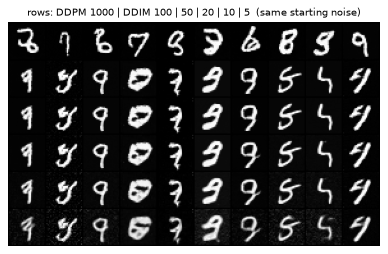

sampler  steps  seconds  confidence  class entropy
DDPM      1000    310.2       0.897          0.986
DDIM       100     34.8       0.863          0.990
DDIM        50     14.9       0.865          0.989
DDIM        20      5.4       0.853          0.988
DDIM        10      2.7       0.839          0.985
DDIM         5      1.2       0.806          0.975


In [3]:
import time

from diffusion_course.ddim import ddim_sample
from diffusion_course.ddpm import ddpm_sample
from diffusion_course.viz import show_images

SHAPE = (256, 1, 28, 28)
noise = torch.randn(SHAPE, device=device)
settings = [("DDPM", 1000), ("DDIM", 100), ("DDIM", 50), ("DDIM", 20), ("DDIM", 10), ("DDIM", 5)]

rows, report = [], []
for name, steps in settings:
    start = time.perf_counter()
    if name == "DDPM":
        images = ddpm_sample(model, schedule, SHAPE, noise=noise, clip_x0=True)
    else:
        images = ddim_sample(model, schedule, SHAPE, num_steps=steps, eta=0.0, noise=noise, clip_x0=True)
    seconds = time.perf_counter() - start
    rows.append(images[:10])
    report.append((name, steps, seconds, judge_samples(classifier, images)))

fig, ax = plt.subplots(figsize=(6, 4))
show_images(torch.cat(rows), ax, nrow=10, title="rows: DDPM 1000 | DDIM 100 | 50 | 20 | 10 | 5  (same starting noise)")
plt.show()

print(f"{'sampler':<8}{'steps':>6}{'seconds':>9}{'confidence':>12}{'class entropy':>15}")
for name, steps, seconds, judged in report:
    print(f"{name:<8}{steps:>6}{seconds:>9.1f}{judged['confidence']:>12.3f}{judged['class_entropy']:>15.3f}")

讀圖讀表：

- 從 DDIM 的每一列往下看，**同一欄的數字大多是同一個**：起始雜訊決定了要生成什麼，步數只影響精細程度。這就是「雜訊 ↔ 影像」的確定性對應。
- DDPM 那一列和 DDIM 不同：DDPM 每步都抽新雜訊，最後走到哪裡是隨機的。
- DDIM 從 100 步降到 50 步，confidence 幾乎不變（0.863 → 0.865），時間卻少一半，比 1000 步的 DDPM 快約 20 倍。再往下降，品質逐步變差（20 步 0.853、10 步 0.839、5 步 0.806；第 09、11 課處理這個極限）。
- 1000 步 DDPM 的 confidence（0.897）比 DDIM 高：差別不在步數，而在隨機性，見下一節。

## 2. $\eta$：確定性與隨機性

50 步，$\eta$ 從 0（DDIM）到 1（DDPM 式的隨機性）。

eta     confidence  class entropy


0.0          0.865          0.989


0.5          0.873          0.983


1.0          0.904          0.987


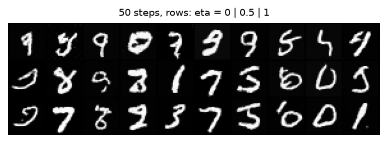

In [4]:
rows = []
print(f"{'eta':<6}{'confidence':>12}{'class entropy':>15}")
for eta in [0.0, 0.5, 1.0]:
    torch.manual_seed(0)
    images = ddim_sample(model, schedule, SHAPE, num_steps=50, eta=eta, noise=noise, clip_x0=True)
    rows.append(images[:10])
    judged = judge_samples(classifier, images)
    print(f"{eta:<6}{judged['confidence']:>12.3f}{judged['class_entropy']:>15.3f}")

fig, ax = plt.subplots(figsize=(6, 2.2))
show_images(torch.cat(rows), ax, nrow=10, title="50 steps, rows: eta = 0 | 0.5 | 1")
plt.show()

## 3. 在雜訊空間插值

DDIM（$\eta = 0$）把每個雜訊對應到唯一一張圖。在兩個雜訊之間插值，就能得到兩張圖之間的過渡。

講義 §2.8：高維常態樣本幾乎都落在半徑 $\sqrt{d}$ 的球殼上。先驗證一下：

In [5]:
d = 28 * 28
z1, z2 = torch.randn(2, d)
print(f"sqrt(d) = {d ** 0.5:.1f}   |z1| = {z1.norm():.1f}   |z2| = {z2.norm():.1f}   |(z1 + z2) / 2| = {((z1 + z2) / 2).norm():.1f}")

sqrt(d) = 28.0   |z1| = 27.5   |z2| = 27.2   |(z1 + z2) / 2| = 19.6


直線插值的中點掉進了球殼內部，是模型從沒看過的「太安靜的雜訊」。比較線性插值與球面插值（slerp）：

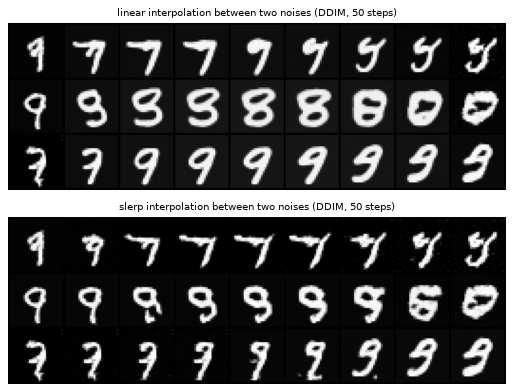

In [6]:
def slerp(a: torch.Tensor, b: torch.Tensor, weight: float) -> torch.Tensor:
    cos_omega = (a.flatten() @ b.flatten()) / (a.norm() * b.norm())
    omega = torch.arccos(cos_omega.clamp(-1, 1))
    return (torch.sin((1 - weight) * omega) * a + torch.sin(weight * omega) * b) / torch.sin(omega)


weights = torch.linspace(0, 1, 9).tolist()
pairs = [(noise[0], noise[1]), (noise[2], noise[3]), (noise[4], noise[5])]
fig, axes = plt.subplots(2, 1, figsize=(7, 5))
for ax, mode in zip(axes, ["linear", "slerp"]):
    batch = []
    for a, b in pairs:
        for w in weights:
            batch.append((1 - w) * a + w * b if mode == "linear" else slerp(a, b, w))
    images = ddim_sample(model, schedule, (len(batch), 1, 28, 28), num_steps=50, noise=torch.stack(batch), clip_x0=True)
    show_images(images, ax, nrow=len(weights), title=f"{mode} interpolation between two noises (DDIM, 50 steps)")
plt.tight_layout()
plt.show()

線性插值的中間幾格筆畫特別平滑、偏粗、背景偏灰：模型收到的是「太安靜的雜訊」（長度只有約 20，而不是 28），生成出過度平滑、偏向平均的圖。slerp 維持在球殼上，每一格的質感都和一般樣本一致。

## 小結

- 不用重新訓練，DDIM 50 步的品質與 100 步相同，速度比 1000 步 DDPM 快約 20 倍。
- 對這個只訓練 2000 步的小模型，50 步時 $\eta = 1$（0.904）反而比 $\eta = 0$（0.865）好：隨機性能「洗掉」一部分模型誤差（講義 §2.7）。確定性取樣的價值在更少的步數，以及需要「雜訊 ↔ 影像」對應的場合（插值、反推）。
- $\eta = 0$ 時雜訊與影像一一對應：同一個雜訊、不同步數，得到的是同一個數字。
- 雜訊空間要用 slerp 插值。

練習（講義 §5）：實作 Heun 版 DDIM、DDIM inversion。